In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
raw_df = pd.read_parquet("ALL_ohlcv_long.parquet")
df = raw_df.copy()

#standardize the date column 
if "date" not in df.columns:
    df = df.reset_index()

df["date"] = pd.to_datetime(df["date"])

In [22]:
# BASIC EDA -- CHECK THE DATA 

print("\nRaw Data Overview")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

print("\nMissing values")
print(df.isna().sum())

print("\nData types")
print(df.dtypes)

print("\nDate range")
print(df["date"].min(), "->", df["date"].max())

print("\nTickers")
print(df["ticker"].unique())


Raw Data Overview
Rows: 25034
Columns: ['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

Missing values
ticker       0
date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

Data types
ticker               object
date         datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
adj_close           float64
volume                int64
dtype: object

Date range
2005-01-03 00:00:00 -> 2025-12-31 00:00:00

Tickers
['GOOGL' 'JPM' 'PFE' 'TSLA' 'XOM']


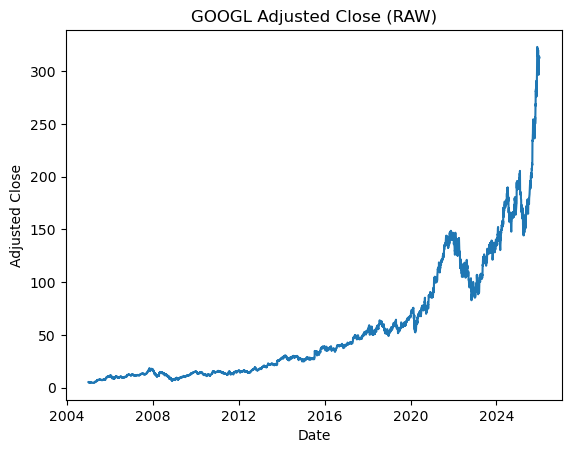

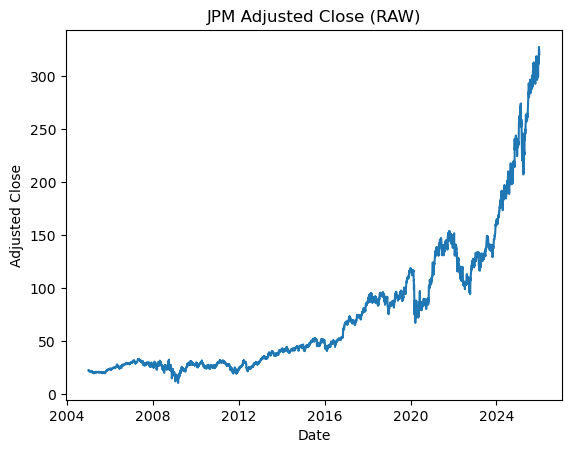

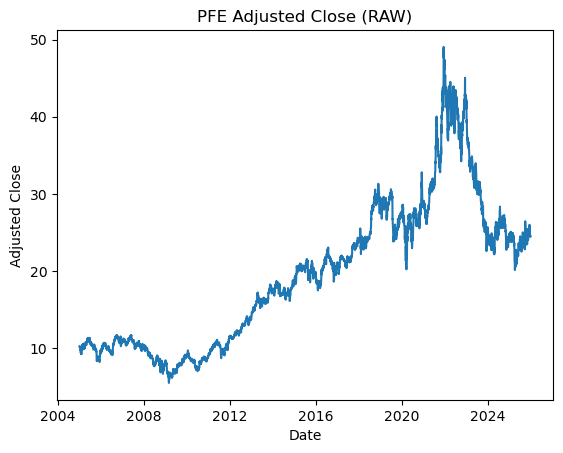

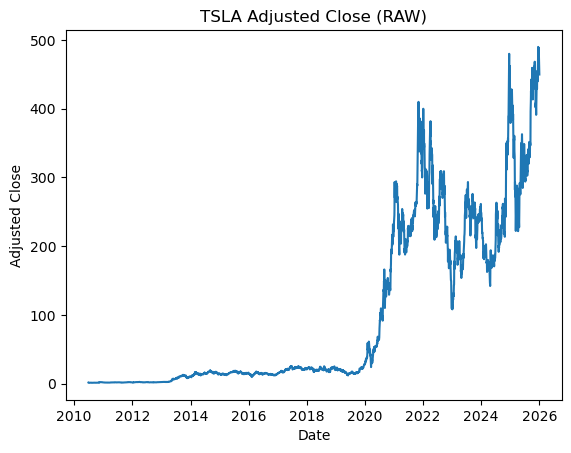

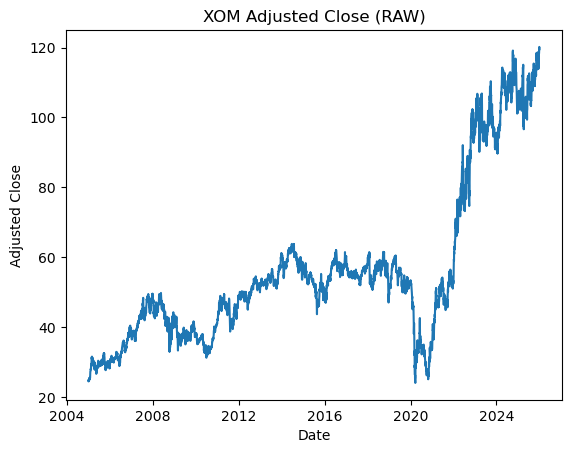

In [24]:
#visualize prices for tickers 

tickers = df["ticker"].unique()

for t in tickers:
    sample = df[df["ticker"] == t].sort_values("date")

    plt.figure()
    plt.plot(sample["date"], sample["adj_close"])
    plt.title(f"{t} Adjusted Close (RAW)")
    plt.xlabel("Date")
    plt.ylabel("Adjusted Close")
    plt.show()

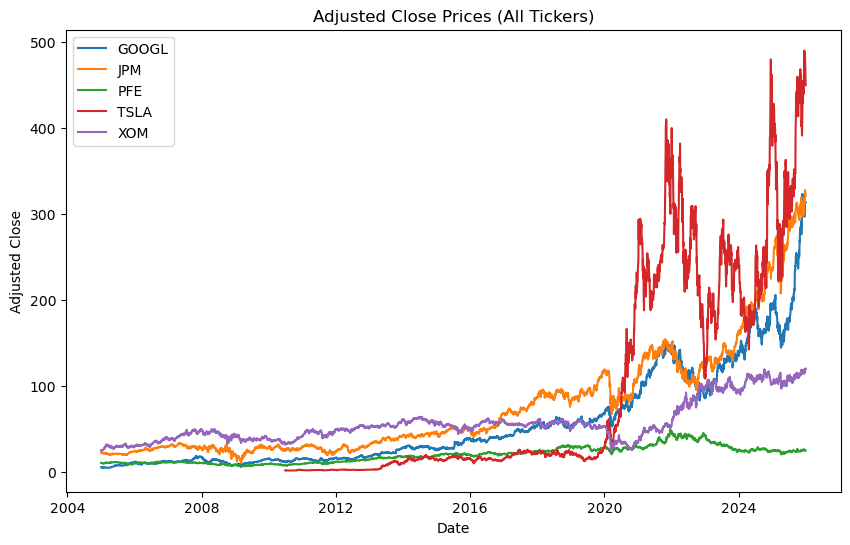

In [26]:
#comparision plot 

plt.figure(figsize=(10,6))

for t in df["ticker"].unique():
    sample = df[df["ticker"] == t].sort_values("date")
    plt.plot(sample["date"], sample["adj_close"], label=t)

plt.title("Adjusted Close Prices (All Tickers)")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.legend()
plt.show()

In [28]:
#remove any duplicates
dupes = df.duplicated(subset=["ticker", "date"])
print("Duplicate rows:", dupes.sum())

df = df.sort_values(["ticker","date"]).drop_duplicates(["ticker","date"])

Duplicate rows: 0


In [32]:
#make sure the rows are still in a numeric as we stored in parquet
cols = ["open","high","low","close","adj_close","volume"]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [34]:
#remove any negative prices
df = df[df["adj_close"] > 0]
df = df.dropna(subset=["adj_close"])

In [40]:
#save cleaned dataset
folder = "/Users/lohitha._.kalepu/Documents/DS492"
df.to_parquet(os.path.join(folder, "ALL_cleaned.parquet"), index=False)